# LASSO Regression (LA) on MHAR Feature Set

**Purpose:** This notebook implements the LASSO regression (LA) model of Tibshirani (1996) on the MHAR feature set for the EURO STOXX 50 index, following the regularization approach described in Christensen, Siggaard, and Veliyev (2023). LASSO augments the HAR-style linear forecasting framework with an L1 penalty that can shrink weak coefficients all the way to zero. This is useful when we want a data-driven balance between parsimony and predictive accuracy. As in the reference paper, we standardize the inputs, tune the penalty parameter in the validation sample, and then evaluate the model in a one-step-ahead rolling-window forecast exercise that is directly comparable to HAR and its extensions.

## 1. Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso


## 2. Data Loading

We use the same `MALL.csv` data source as in the benchmark notebooks so that the regularized models are evaluated on the exact same information set and forecast period.

In [2]:
# Load MALL dataset
MALL = pd.read_csv("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv")
MALL["Date"] = pd.to_datetime(MALL["Date"])
MALL = MALL.set_index("Date")

print(f"Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"Number of observations: {len(MALL)}")
display(MALL[["RVD", "RVW", "RVM", "RV_target"]].head())


Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,RV_target
Date,,,,
1999-01-05,0.000078,0.000093,0.000129,0.000058
1999-01-06,0.000058,0.000092,0.000123,0.000139
1999-01-07,0.000139,0.000102,0.000121,0.000108
1999-01-08,0.000108,0.000106,0.000112,0.000166
1999-01-11,0.000166,0.000110,0.000110,0.000115


## 3. Data Split

To remain comparable with HAR, LogHAR, LevHAR, SHAR, and HARQ, we use the same 70/10/20 split into training, validation, and test sets. The validation set is used only for tuning the regularization strength, while the test set is reserved for the final out-of-sample evaluation.

In [3]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 4. Feature Set Construction and Standardization

The reference paper emphasizes standardization for regularized regressions. We therefore scale the MHAR predictors using moments from the training sample only and carry those scaling constants through the rest of the exercise. The dependent variable remains in levels so that the resulting forecasts and accuracy measures stay directly comparable with the benchmark HAR notebooks.

In [4]:
# Define target and MHAR feature set
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

# Split into train, validation and test sets
X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)

# Scale full dataset using training-set parameters
X_scaled = (X_MHAR - X_mean) / X_std

X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_train_scaled.mean(axis=0).round(6)}")
print(f"  Std:   {X_train_scaled.std(axis=0).round(6)}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [-0.  0. -0.]
  Std:   [1. 1. 1.]


## 5. LASSO Model Specification and Hyperparameter Tuning

Following the paper, we tune the regularization parameter over a broad logarithmic grid so that both weak and strong shrinkage remain feasible candidates. We first search over the initial range and then verify that the selected value is not sitting mechanically on a boundary.

Grid size: 1000
Alpha range: 1.00e-05 to 1.00e+02
Optimal alpha: 2.808332e-05
Validation MSE: 1.702536e-08
Non-zero coefficients at optimum: 3
Position in grid: 64 / 1000


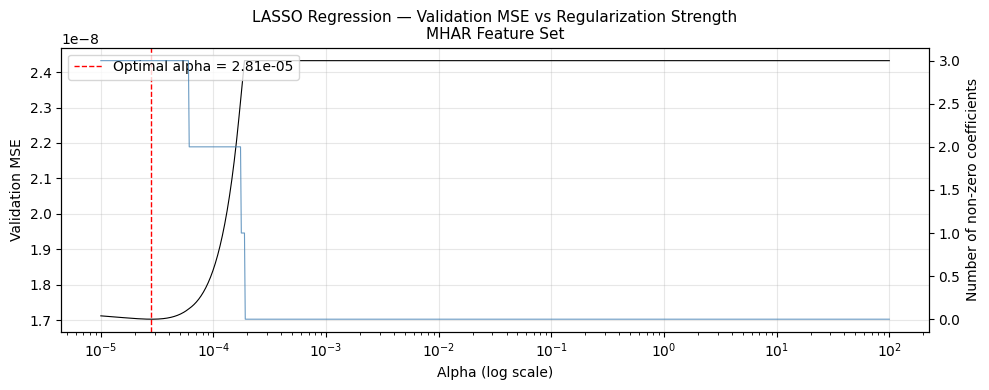

In [5]:
# Define alpha grid following the paper
# 1000 points on the natural regularization scale from 1e-5 to 1e2
alpha_grid = np.logspace(-5, 2, 1000)

val_mse = []
nonzero_counts = []

for alpha in alpha_grid:
    model = Lasso(alpha=alpha, fit_intercept=True, max_iter=100000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    val_mse.append(np.mean((y_val - y_pred) ** 2))
    nonzero_counts.append(np.sum(np.abs(model.coef_) > 1e-12))

best_idx = int(np.argmin(val_mse))
optimal_alpha = alpha_grid[best_idx]
optimal_val_mse = val_mse[best_idx]

print(f"Grid size: {len(alpha_grid)}")
print(f"Alpha range: {alpha_grid[0]:.2e} to {alpha_grid[-1]:.2e}")
print(f"Optimal alpha: {optimal_alpha:.6e}")
print(f"Validation MSE: {optimal_val_mse:.6e}")
print(f"Non-zero coefficients at optimum: {nonzero_counts[best_idx]}")
print(f"Position in grid: {best_idx} / {len(alpha_grid)}")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.semilogx(alpha_grid, val_mse, color="black", linewidth=0.8)
ax1.axvline(optimal_alpha, color="red", linestyle="--", linewidth=1.0, label=f"Optimal alpha = {optimal_alpha:.2e}")
ax1.set_xlabel("Alpha (log scale)")
ax1.set_ylabel("Validation MSE")
ax1.set_title("LASSO Regression — Validation MSE vs Regularization Strength\nMHAR Feature Set", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.semilogx(alpha_grid, nonzero_counts, color="steelblue", linewidth=0.8, alpha=0.8)
ax2.set_ylabel("Number of non-zero coefficients")
plt.tight_layout()
plt.show()


## 6. Rolling Window Estimation and Forecasting

As in the benchmark models, the rolling window length equals the initial training plus validation sample. We keep the alpha selected in the initial validation exercise fixed during the test-period forecasting loop so that the implementation mirrors the regularized workflow in the paper and the existing ridge notebook.

In [6]:
fixed_alpha = optimal_alpha
window_size = n_train + n_val

print(f"Fixed alpha from validation tuning: {fixed_alpha:.6e}")
print(f"Rolling window length: {window_size}")

forecasts_LA = []
dates_test = []
nonzero_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    model_final = Lasso(alpha=fixed_alpha, fit_intercept=True, max_iter=100000)
    model_final.fit(X_window, y_window)

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = model_final.predict(X_forecast)[0]
    forecast = max(forecast, y_window.min())

    forecasts_LA.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    nonzero_path.append(np.sum(np.abs(model_final.coef_) > 1e-12))

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_LA)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Average number of active predictors: {np.mean(nonzero_path):.2f}")


Fixed alpha from validation tuning: 2.808332e-05
Rolling window length: 4390
  Day  100/1099 | Date: 2016-09-08 | Elapsed: 0.0 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 0.0 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 0.0 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 0.0 min
  Day  500/1099 | Date: 2018-04-04 | Elapsed: 0.0 min


  Day  600/1099 | Date: 2018-08-22 | Elapsed: 0.0 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 0.0 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 0.0 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 0.0 min
  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 0.0 min

Total estimation time: 0.0 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06
Average number of active predictors: 3.00


## 7. Save Forecasts

We save the forecast series and the summary error metrics using the same output structure as the benchmark models so that later comparison notebooks can load the results directly.

In [7]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_LA = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_LA
}, index=test_dates)

errors_LA = results_LA["RV_actual"] - results_LA["RV_forecast"]
mse_LA = np.mean(errors_LA ** 2)

results_LA.to_csv(os.path.join(forecast_path, "forecasts_LA.csv"))

mse_summary_LA = pd.DataFrame({
    "Model": ["LA"],
    "MSE": [mse_LA],
    "RMSE": [np.sqrt(mse_LA)],
    "MAE": [errors_LA.abs().mean()],
    "Mean_Error": [errors_LA.mean()],
}).set_index("Model")

mse_summary_LA.to_csv(os.path.join(forecast_path, "mse_summary_LA.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Rows saved: {len(results_LA)}")
print(f"LASSO test-set MSE: {mse_LA:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Rows saved: 1099
LASSO test-set MSE: 2.379929e-08


## 8. Out-of-Sample Performance Evaluation

We compare the LASSO forecasts with the HAR benchmark on the identical test period. This keeps the interpretation aligned with the rest of the thesis notebook sequence.

In [8]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR = pd.read_csv(
    os.path.join(forecast_path, "forecasts_HAR.csv"),
    index_col=0,
    parse_dates=True
)

mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"]) ** 2)
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
rel_mse_LA = mse_LA / mse_HAR

print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {1.0:>10.4f}")
print(f"{'LA':<10} {mse_LA:>12.6e} {np.sqrt(mse_LA):>12.6e} {errors_LA.abs().mean():>12.6e} {errors_LA.mean():>12.6e} {rel_mse_LA:>10.4f}")
print("-" * 70)
print(f"\nLA vs HAR: {'outperforms' if rel_mse_LA < 1 else 'underperforms'} by {abs(1 - rel_mse_LA) * 100:.2f}%")


Out-of-sample performance (2016-04-21 to 2020-08-06):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
LA         2.379929e-08 1.542702e-04 6.410134e-05 -1.166292e-05     1.0714
----------------------------------------------------------------------

LA vs HAR: underperforms by 7.14%


## 9. Forecast Visualization

To make the forecast path easy to compare with the benchmark models, we convert realized variance into annualized volatility before plotting the actual and forecasted series.

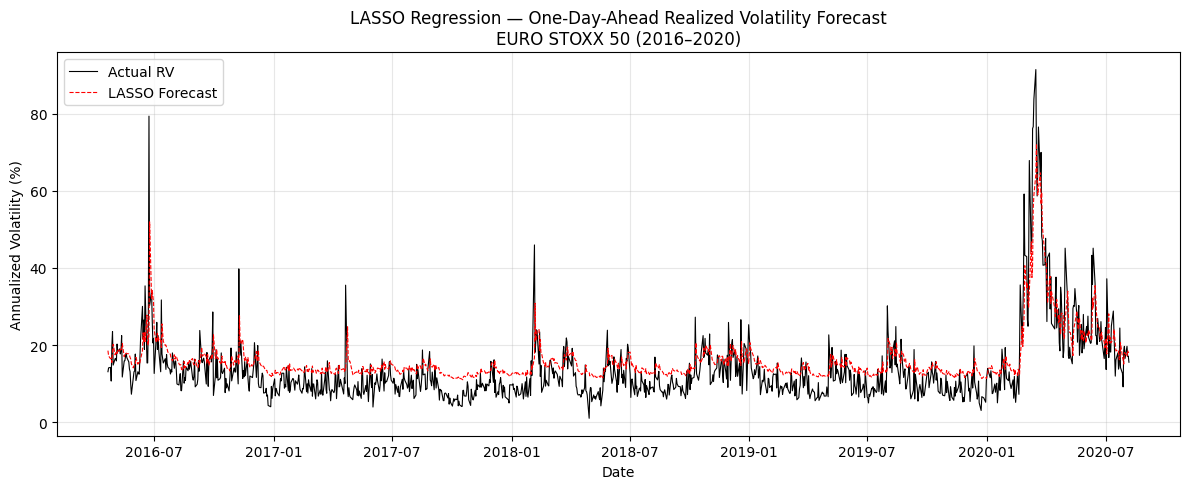


Summary of forecast errors:
Mean error:  -1.166292e-05
RMSE:        1.542702e-04
MAE:         6.410134e-05
Average active coefficients in rolling estimation: 3.00


In [9]:
results_plot_LA = pd.DataFrame({
    "Actual": np.sqrt(results_LA["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_LA["RV_forecast"] * 252) * 100
}, index=results_LA.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_LA["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot_LA["Forecast"], label="LASSO Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("LASSO Regression — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print(f"Mean error:  {errors_LA.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_LA):.6e}")
print(f"MAE:         {errors_LA.abs().mean():.6e}")
print(f"Average active coefficients in rolling estimation: {np.mean(nonzero_path):.2f}")
